# MariaDB Benchmark Results Analysis - SSD

This notebook analyzes the results of TPC-C benchmarks conducted on a MariaDB database across various terminal counts.

## Methodology
- **Base State**: The run with 2 terminals (`results_ssd_term2`) was performed first and serves as the baseline for cumulative metrics.
- **Deltas**: For each run, statistics are calculated as deltas from the previous run in chronological order.
- **Comparisons**: The 2-terminal run is used for baseline calculation but excluded from terminal count comparisons (1, 10, 20, 30, 40, 50, 60, 70).

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
def load_benchmark_data(base_dir):
    results = []
    dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and 'results_ssd_term' in d]
    
    for d in dirs:
        dir_path = os.path.join(base_dir, d)
        files = os.listdir(dir_path)
        
        summary_file = next((f for f in files if f.endswith('.summary.json')), None)
        metrics_file = next((f for f in files if f.endswith('.metrics.json')), None)
        
        if not summary_file or not metrics_file:
            continue
            
        with open(os.path.join(dir_path, summary_file), 'r') as f:
            summary = json.load(f)
        
        with open(os.path.join(dir_path, metrics_file), 'r') as f:
            metrics = json.load(f)
            
        terminals = int(summary.get('terminals', d.split('term')[-1]))
        start_ts = summary.get('Start timestamp (milliseconds)', 0)
        
        results.append({
            'dir': d,
            'terminals': terminals,
            'start_ts': start_ts,
            'summary': summary,
            'metrics': metrics
        })
    
    # Sort by start timestamp to calculate deltas correctly
    results.sort(key=lambda x: x['start_ts'])
    return results

data = load_benchmark_data('data/')
print(f"Loaded {len(data)} benchmark runs.")

Loaded 9 benchmark runs.


In [3]:
def process_stats(data):
    processed = []
    
    for i in range(len(data)):
        curr = data[i]
        prev = data[i-1] if i > 0 else None
        
        res = {
            'terminals': curr['terminals'],
            'throughput': curr['summary']['Throughput (requests/second)'],
            'goodput': curr['summary'].get('Goodput (requests/second)', 0),
            'avg_latency': curr['summary']['Latency Distribution']['Average Latency (microseconds)'] / 1000.0, # ms
            'p95_latency': curr['summary']['Latency Distribution']['95th Percentile Latency (microseconds)'] / 1000.0, # ms
            'measured_requests': curr['summary'].get('Measured Requests', 0)
        }
        
        # MariaDB metrics (cumulative status variables)
        if prev:
            # Queries delta
            res['queries_delta'] = int(curr['metrics'].get('queries', 0)) - int(prev['metrics'].get('queries', 0))
            
            # Buffer Pool Activity (mapped to descriptive Physical I/O names)
            res['logical_reads'] = int(curr['metrics'].get('innodb_buffer_pool_read_requests', 0)) - int(prev['metrics'].get('innodb_buffer_pool_read_requests', 0))
            res['disk_reads_physical'] = int(curr['metrics'].get('innodb_buffer_pool_reads', 0)) - int(prev['metrics'].get('innodb_buffer_pool_reads', 0))
            res['disk_writes_physical'] = int(curr['metrics'].get('innodb_buffer_pool_pages_flushed', 0)) - int(prev['metrics'].get('innodb_buffer_pool_pages_flushed', 0))
            
            # Row Activity
            res['rows_read'] = int(curr['metrics'].get('rows_read', 0)) - int(prev['metrics'].get('rows_read', 0))
            res['rows_sent'] = int(curr['metrics'].get('rows_sent', 0)) - int(prev['metrics'].get('rows_sent', 0))
        else:
            res['queries_delta'] = 0
            res['logical_reads'] = 0
            res['disk_reads_physical'] = 0
            res['disk_writes_physical'] = 0
            res['rows_read'] = 0
            res['rows_sent'] = 0
            
        processed.append(res)
        
    return pd.DataFrame(processed)

df = process_stats(data)
# Filter out the baseline (term 2) and sort by terminals
df_plot = df[df['terminals'] != 2].sort_values('terminals')
df_plot

,terminals,throughput,goodput,avg_latency,p95_latency,measured_requests,queries_delta,logical_reads,disk_reads_physical,disk_writes_physical,rows_read,rows_sent
1,1,61.702498,67.642498,16.200,35.879,74043,1925705,26047411,891491,550271,0,0
2,10,463.242493,506.837493,21.583,44.656,555891,14452771,193217166,21098655,7721138,0,0
3,20,634.423328,695.447494,31.519,69.758,761308,19842580,264812787,36649995,12290062,0,0
4,30,703.164998,769.969164,42.657,103.515,843798,21952405,293380209,44133501,13831784,0,0
5,40,734.607499,804.821665,54.443,133.350,881529,22938993,306827748,49155848,14606258,0,0
6,50,750.450828,821.909161,66.613,159.641,900541,23446079,312739476,51917785,15070333,0,0
7,60,742.399133,813.399130,80.801,183.403,890879,23159433,309344698,53829651,15001147,0,0
8,70,759.534141,831.480805,92.136,206.953,911441,23695955,315825320,54883193,15320274,0,0


## Throughput and Goodput Analysis

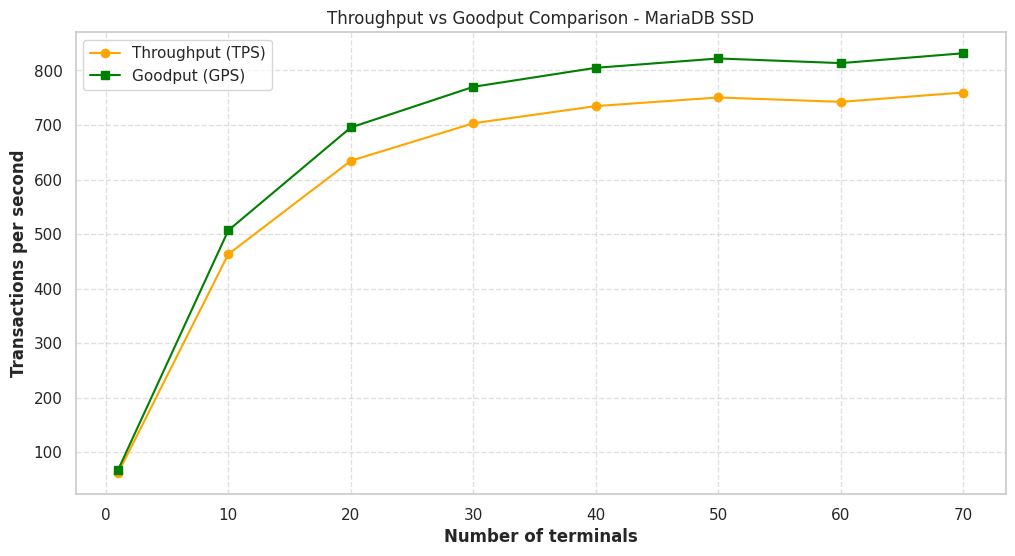

In [4]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(df_plot['terminals'], df_plot['throughput'], label='Throughput (TPS)', color='orange', marker='o')
plt.plot(df_plot['terminals'], df_plot['goodput'], label='Goodput (GPS)', color='green', marker='s')
plt.xlabel('Number of terminals', fontsize=12, fontweight='bold')
plt.ylabel('Transactions per second', fontsize=12, fontweight='bold')
plt.title('Throughput vs Goodput Comparison - MariaDB SSD')
plt.legend()
plt.show()

## Latency Distribution (Box Plot)

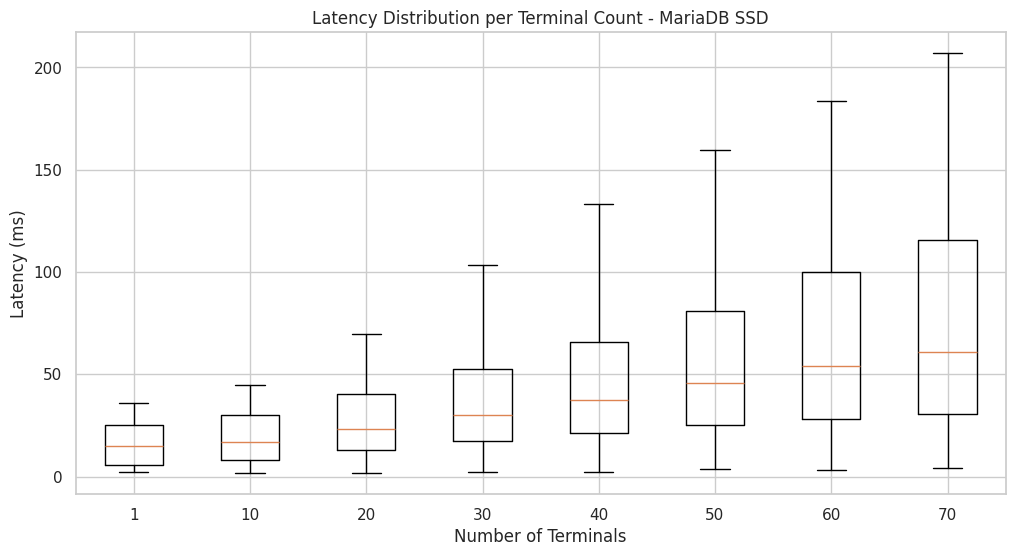

In [5]:
def prepare_boxplot_data(data):
    stats_list = []
    for entry in data:
        if entry['terminals'] == 2:
            continue
        dist = entry['summary']['Latency Distribution']
        stats_list.append({
            'label': str(entry['terminals']),
            'med': dist['Median Latency (microseconds)'] / 1000.0,
            'q1': dist['25th Percentile Latency (microseconds)'] / 1000.0,
            'q3': dist['75th Percentile Latency (microseconds)'] / 1000.0,
            'whislo': dist['Minimum Latency (microseconds)'] / 1000.0,
            'whishi': dist['95th Percentile Latency (microseconds)'] / 1000.0,
            'fliers': []
        })
    return stats_list

bx_stats = prepare_boxplot_data(data)
bx_stats.sort(key=lambda x: int(x['label']))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bxp(bx_stats, showfliers=False)
ax.set_ylabel('Latency (ms)')
ax.set_xlabel('Number of Terminals')
ax.set_title('Latency Distribution per Terminal Count - MariaDB SSD')
plt.show()

## Throughput and Latency Overview

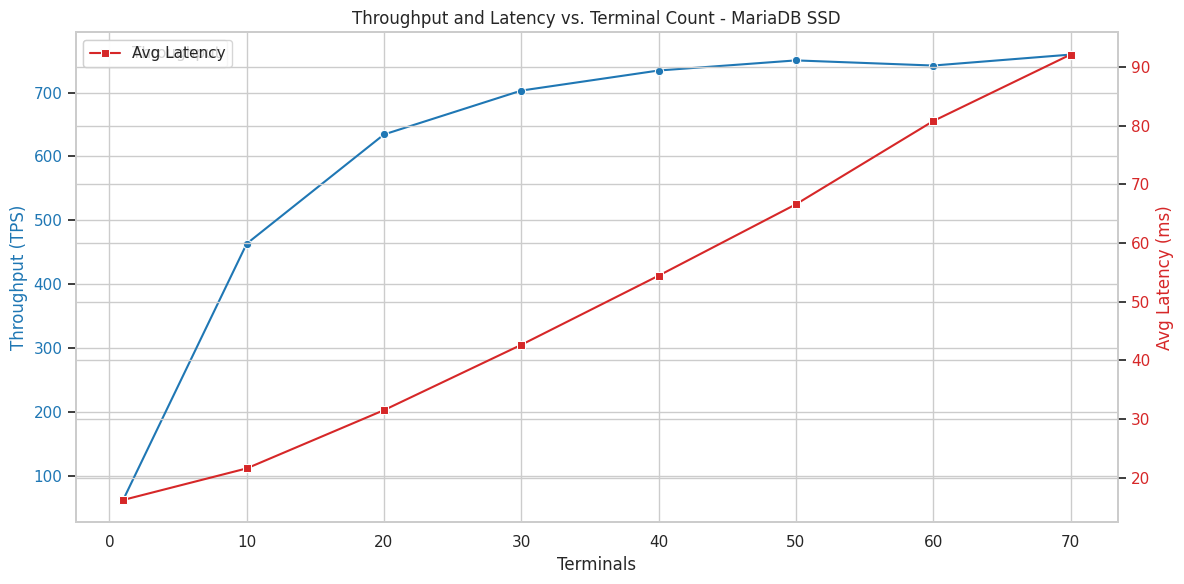

In [6]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Terminals')
ax1.set_ylabel('Throughput (TPS)', color='tab:blue')
sns.lineplot(data=df_plot, x='terminals', y='throughput', marker='o', ax=ax1, color='tab:blue', label='Throughput')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Latency (ms)', color='tab:red')
sns.lineplot(data=df_plot, x='terminals', y='avg_latency', marker='s', ax=ax2, color='tab:red', label='Avg Latency')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Throughput and Latency vs. Terminal Count - MariaDB SSD')
fig.tight_layout()
plt.show()

## Database Activity (Queries and Rows)

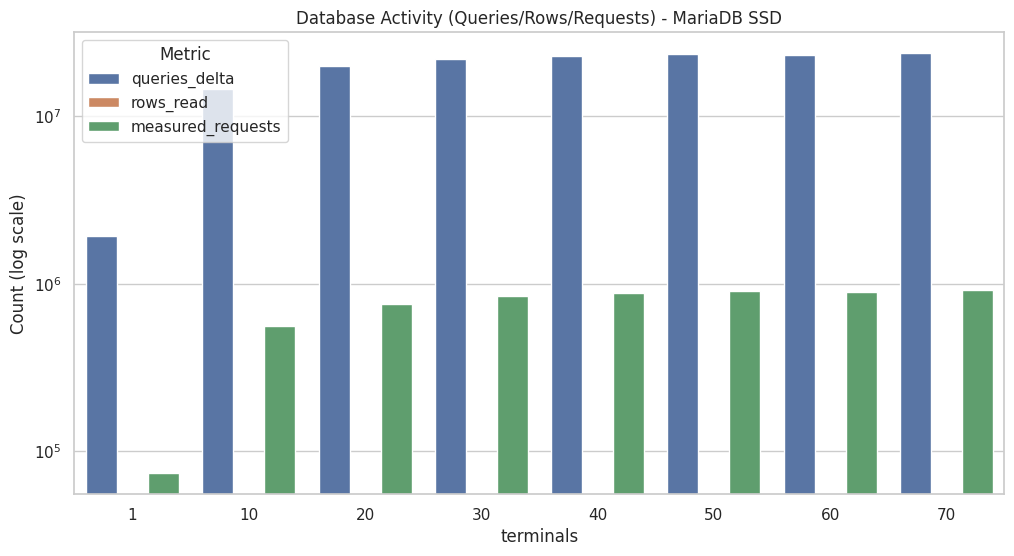

In [7]:
cols = ['queries_delta', 'disk_reads_physical', 'measured_requests']
df_melted = df_plot.melt(id_vars='terminals', value_vars=cols, var_name='Metric', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='terminals', y='Count', hue='Metric')
plt.title('Database Activity (Queries/Disk Reads/Requests) - MariaDB SSD')
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.show()

## Block I/O Activity (InnoDB Buffer Pool)

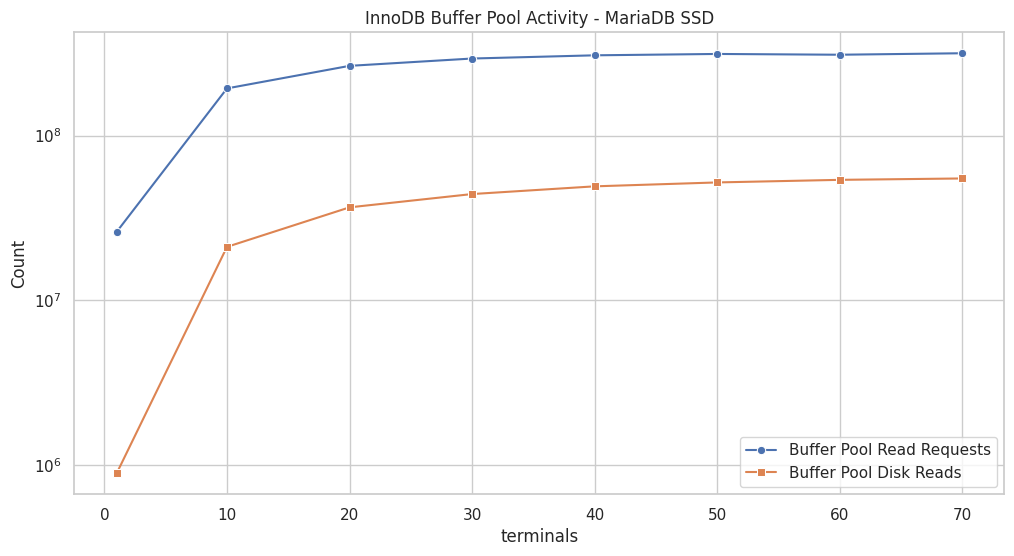

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='terminals', y='logical_reads', marker='o', label='Logical Reads (from memory)')
sns.lineplot(data=df_plot, x='terminals', y='disk_reads_physical', marker='s', label='Physical Disk Reads')
plt.title('InnoDB Buffer Pool Activity (Physical vs Logical) - MariaDB SSD')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.show()